## Задание №1

Выполните следующие задания.
1. Нарисуйте призму в исходном положении и сверьтесь с Рис. 10.
2. С помощью матрицы Эйлера поверните его на 90° вокруг оси 𝑂𝑦.
3. Задайте координаты из таблицы Таблица 9 в виде массива.
4. Отобразите результат вращения, сверьтесь с рисунком Рис. 11, а также с координатами
из таблицы Таблица 9 путем вычитания массивов.
5. Аналогично, поверните призму из исходного положения на 90° вокруг оси 𝑂𝑦, а затем
на угол 90°, вокруг оси 𝑂𝑧. Сверьтесь с рисунком Рис.  12. А также путем вычитания
массивов с таблицей Таблица 10.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, FloatSlider
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import ipywidgets as widgets
from matplotlib.patches import Circle
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML

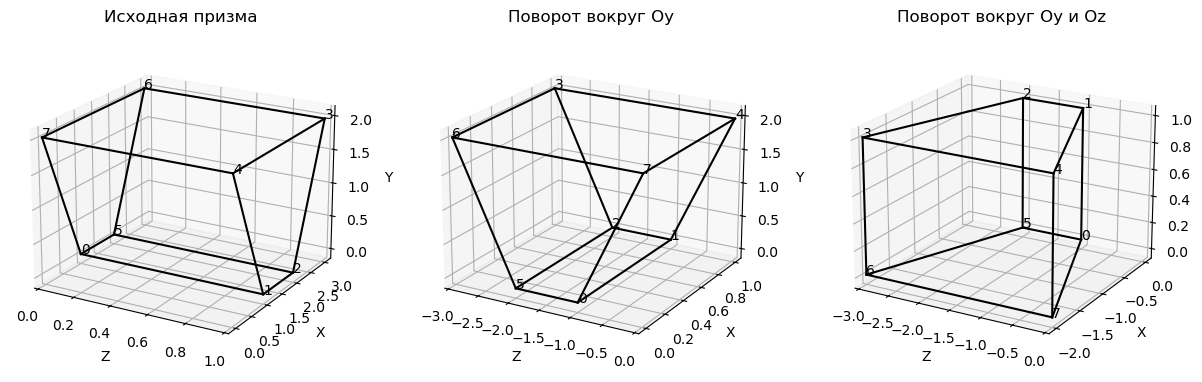

In [2]:
points = np.array([[1,0,0],[1,0,1],[2,0,1],[3,2,1],[0,2,1],[2,0,0],[3,2,0],[0,2,0]])
edges = [(0,1),(1,2),(2,3),(3,4),(4,1),(0,5),(5,6),(6,7),(7,0),(5,2),(6,3),(7,4)]
theta = np.radians(90)
Ry = np.array([[np.cos(theta), 0, np.sin(theta)], [0, 1, 0], [-np.sin(theta), 0, np.cos(theta)]])
Rz = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
def plot_prism(ax, pts, title):
    for i, j in edges:
        ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], [pts[i,2], pts[j,2]], color='black')
    for i, p in enumerate(pts):
        ax.text(p[0], p[1], p[2], str(i))
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.view_init(elev=20, azim=-60, vertical_axis='y')
fig = plt.figure(figsize=(15,5))
ax1 = fig.add_subplot(131, projection='3d')
plot_prism(ax1, points, "Исходная призма")
ax2 = fig.add_subplot(132, projection='3d')
plot_prism(ax2, points @ Ry.T, "Поворот вокруг Oy")
ax3 = fig.add_subplot(133, projection='3d')
plot_prism(ax3, points @ Ry.T @ Rz.T, "Поворот вокруг Oy и Oz")
plt.show()

In [5]:
tab9 = np.array([[0,0,-1],[1,0,-1],[1,0,-2],[1,2,-3],[1,2,0],[0,0,-2],[0,2,-3],[0,2,0]])
tab10 = np.array([[0,0,-1],[0,1,-1],[0,1,-2],[-2,1,-3],[-2,1,0],[0,0,-2],[-2,0,-3],[-2,0,0]])
print("Разница с табл.9:\n", points @ Ry.T - tab9)
print("\nРазница с табл.10:\n", points @ Ry.T @ Rz.T - tab10)

Разница с табл.9:
 [[6.12323400e-17 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.11022302e-16]
 [2.22044605e-16 0.00000000e+00 0.00000000e+00]
 [2.22044605e-16 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.12323400e-17]
 [1.22464680e-16 0.00000000e+00 0.00000000e+00]
 [1.83697020e-16 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]

Разница с табл.10:
 [[3.74939946e-33 6.12323400e-17 0.00000000e+00]
 [6.12323400e-17 0.00000000e+00 1.11022302e-16]
 [6.12323400e-17 2.22044605e-16 0.00000000e+00]
 [0.00000000e+00 4.44089210e-16 0.00000000e+00]
 [0.00000000e+00 2.22044605e-16 6.12323400e-17]
 [7.49879891e-33 1.22464680e-16 0.00000000e+00]
 [0.00000000e+00 3.06161700e-16 0.00000000e+00]
 [0.00000000e+00 1.22464680e-16 0.00000000e+00]]


## Задание №2

Выполните следующие задания.

1. Задайте пирамиду с квадратным основанием координаты вершин которой указанны в
таблице 11, а сама пирамида изображена на рисунке Рис. 13.
2. Переверните пирамиду вверх ногами, как это показано на том же рисунке. Для такого
переворота следует вначале повернуть пирамиду вокруг оси 𝑂𝑥, а затем поднять на 2
единицы вверх по оси 𝑂𝑧. Сверьтесь с таблицей Таблица 12
3. Сделайте ползунок который позволит двигать пирамиду вверх-вниз и вращать на произвольный угол.

In [3]:
p = np.array([[-0.5,-0.5,0],[0.5,-0.5,0],[0.5,0.5,0],[-0.5,0.5,0],[0,0,0.71]])
edges = [(0,1),(1,2),(2,3),(3,0),(0,4),(1,4),(2,4),(3,4)]
def rodrigues(theta, a):
    a = a / np.linalg.norm(a)
    ax,ay,az = a
    A = np.array([[0,-az,ay],[az,0,-ax],[-ay,ax,0]])
    I = np.eye(3)
    return I + np.sin(theta)*A + (1-np.cos(theta))*(A@A)
p = p @ rodrigues(np.radians(180), [1,0,0]).T
p[:,2] += 2 #все строки, колонка 2
def draw(angle, up):
    R = rodrigues(np.radians(angle), [0,1,0])
    p_rot = p @ R.T
    p_rot[:,2] += up
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    for i,j in edges:
        ax.plot([p_rot[i,0],p_rot[j,0]], [p_rot[i,1],p_rot[j,1]], [p_rot[i,2],p_rot[j,2]], 'k-')
    ax.scatter(p_rot[:,0], p_rot[:,1], p_rot[:,2], c='r')
    ax.set_xlim([-2,2])
    ax.set_ylim([-2,2])
    ax.set_zlim([0,4])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.view_init(elev=20, azim=-60)
    plt.show()
interact(draw, angle=widgets.IntSlider(min=0,max=360,step=5,value=0,description='Угол'),up=widgets.FloatSlider(min=-1,max=2,step=0.1,value=0,description='Вверх/вниз'))

interactive(children=(IntSlider(value=0, description='Угол', max=360, step=5), FloatSlider(value=0.0, descript…

<function __main__.draw(angle, up)>

## Задание №3

Выполните следующие задания.

1. Задайте октаэдр, координаты его вершин указанны в таблице Таблица 13. Отобразите
октаэдр и сверьтесь с Рис. 14.
2. Напишите программу, которая будет вращать октаэдр вокруг оси 𝑂𝑦 с помощью задания
параметров Родрига–Гамильтона. Создайте ползунок, который изменяет угол вращения 𝜃 от 0° до 360° и вращает пирамиду.
3. Напишите программу, которая будет вращать октаэдр вокруг оси проведенной от вершины 3 к вершине 1 с помощью кватернионов. Создайте ползунок, который изменяет
угол вращения 𝜃 от 0° до 360° и вращает пирамиду

In [4]:
p = np.array([[-0.53,-0.85,0],[0.85,-0.53,0],[0.53,0.85,0],[-0.85,0.53,0],[0,0,-1],[0,0,1]])
f = [[0,1,4],[1,2,4],[2,3,4],[3,0,4],[0,1,5],[1,2,5],[2,3,5],[3,0,5]]
def draw(a, b):
    fig = plt.figure(figsize=(10,5))
    ra = np.radians(a)
    l0, l = np.cos(ra/2), np.sin(ra/2)*np.array([0,1,0])
    v1 = np.array([v + 2*l0*np.cross(l,v) + 2*np.cross(l, np.cross(l,v)) for v in p])
    ax = (p[1]-p[3])/np.linalg.norm(p[1]-p[3])
    ra2 = np.radians(b)
    q = np.array([np.cos(ra2/2), np.sin(ra2/2)*ax[0], np.sin(ra2/2)*ax[1], np.sin(ra2/2)*ax[2]])
    def mul(x,y):
        return np.array([x[0]*y[0]-x[1]*y[1]-x[2]*y[2]-x[3]*y[3],x[0]*y[1]+x[1]*y[0]+x[2]*y[3]-x[3]*y[2],x[0]*y[2]-x[1]*y[3]+x[2]*y[0]+x[3]*y[1],x[0]*y[3]+x[1]*y[2]-x[2]*y[1]+x[3]*y[0]])
    v2 = np.array([mul(mul(q, [0,v[0],v[1],v[2]]), [q[0],-q[1],-q[2],-q[3]])[1:] for v in p])
    for i, verts in enumerate([v1, v2]):
        ax = fig.add_subplot(121+i, projection='3d')
        ax.add_collection3d(Poly3DCollection([[verts[j] for j in face] for face in f], alpha=0.4, color=['black','black'][i], edgecolor='k'))
        ax.scatter(verts[:,0], verts[:,1], verts[:,2], c='r')
        ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.set_zlim(-1.5,1.5)
        ax.view_init(25,-60)
        
        ax.set_title(['Родрига-Гамильтона (Oy)', 'Кватернионы'][i])
    plt.show()
interact(draw, a=(0,360,5), b=(0,360,5))

interactive(children=(IntSlider(value=180, description='a', max=360, step=5), IntSlider(value=180, description…

<function __main__.draw(a, b)>

## Задание №4

Пирамиду из задания №3 поверните вокруг оси, проходящей через вершину 3 параллельно оси 𝑂𝑦, как это показано на рисунке Рис.  15. Используйте любой способ. Также
создайте ползунок, который позволяет вращать пирамиду с шагом 1°

In [5]:
p = np.array([[-0.5, 0, -0.5], [0.5, 0, -0.5],[0.5, 0, 0.5],[-0.5, 0, 0.5],[0, 1, 0]])
edges = [(0,1),(1,2),(2,3),(3,0),(0,4),(1,4),(2,4),(3,4)]
def rodrigues(theta, a):
    a = a / np.linalg.norm(a)
    ax,ay,az = a
    A = np.array([[0,-az,ay],[az,0,-ax],[-ay,ax,0]])
    return np.eye(3) + np.sin(theta)*A + (1-np.cos(theta))*(A@A)
def draw(angle):
    v3 = np.array([-0.5, 0, 0.5])
    axis = np.array([0, 1, 0])
    p_centered = p - v3
    R = rodrigues(np.radians(angle), axis)
    p_rot = p_centered @ R.T + v3
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    for i,j in edges:
        ax.plot([p_rot[i,0],p_rot[j,0]], [p_rot[i,1],p_rot[j,1]], [p_rot[i,2],p_rot[j,2]], 'k-')
    ax.scatter(p_rot[:,0], p_rot[:,1], p_rot[:,2], c='r')
    ax.plot([v3[0], v3[0]], [-1, 2], [v3[2], v3[2]], 'b--', linewidth=2)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=20, azim=-60, vertical_axis='y')
    ax.set_xlim([-2,2])
    ax.set_ylim([-1,2])
    ax.set_zlim([-2,2])
    plt.show()
interact(draw, angle=widgets.IntSlider(min=0,max=360,step=1,value=0,description='Угол'))

interactive(children=(IntSlider(value=0, description='Угол', max=360), Output()), _dom_classes=('widget-intera…

<function __main__.draw(angle)>